# Stage 06: Data Preprocessing

This notebook prepares S&P 500 market data for later analysis. It uses a deterministic dirty-data teaching fixture based on the Stage 05 raw snapshot, so the original source snapshot stays unchanged.

## Preprocessing Plan

- Convert dates, currency-formatted prices, and comma-formatted volumes to usable types.
- Drop the intentionally invalid date because it cannot be placed in a time series.
- Interpolate one missing closing price because it lies between two observed trading days.
- Fill one missing volume value with the median because volume is nonnegative and can be skewed.
- Standardize the ticker and create MinMax/standard-scaled features for downstream models.

In [1]:
from datetime import datetime, timezone
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'homework' / 'homework06').exists()
)
HOMEWORK_DIR = REPO_ROOT / 'homework' / 'homework06'
load_dotenv(HOMEWORK_DIR / '.env')
RAW_DIR = HOMEWORK_DIR / os.environ.get('DATA_DIR_RAW', 'data/raw')
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get('DATA_DIR_PROCESSED', 'data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR / 'src'))
from preprocess_utils import clean_market_prices, missingness_summary, validate_cleaned_prices

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
print('Raw directory:', RAW_DIR.resolve())
print('Processed directory:', PROCESSED_DIR.resolve())

/Users/yifang/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/s5/8svqh9px7c37nc9bv7gsq6gh0000gn/T/matplotlib-k9hqzc51 because there was an issue with the default path (/Users/yifang/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Raw directory: /Users/yifang/bootcamp_Yifang_Qiu/homework/homework06/data/raw
Processed directory: /Users/yifang/bootcamp_Yifang_Qiu/homework/homework06/data/processed


## Create a Reproducible Dirty-Data Fixture
The actual Stage 05 snapshot has no missing values. For this lesson, the controlled fixture creates realistic formatting and missingness issues without modifying that original input.

In [2]:
stage05_raw_dir = REPO_ROOT / 'homework' / 'homework05' / 'data' / 'raw'
source_files = sorted(stage05_raw_dir.glob('sp500_prices_*.csv'))
if not source_files:
    raise FileNotFoundError('Run the Stage 05 notebook first so a raw CSV is available.')

source_path = source_files[-1]
source_data = pd.read_csv(source_path, parse_dates=['date'])
dirty_data = source_data.copy()
dirty_data['date'] = dirty_data['date'].dt.strftime('%Y-%m-%d')
dirty_data['ticker'] = '  ^gspc  '
dirty_data['close'] = dirty_data['close'].map(lambda value: f'${value:,.2f}')
dirty_data['volume'] = dirty_data['volume'].map(lambda value: f'{value:,}')
dirty_data.loc[4, 'close'] = pd.NA
dirty_data.loc[9, 'volume'] = pd.NA
dirty_data.loc[15, 'date'] = 'not-a-date'

dirty_path = RAW_DIR / f'sp500_prices_dirty_fixture_{RUN_TIMESTAMP}.csv'
dirty_data.to_csv(dirty_path, index=False)
print(f'Saved deterministic dirty fixture: {dirty_path.name}')
dirty_data.head(10)

Saved deterministic dirty fixture: sp500_prices_dirty_fixture_20260820-050305.csv


,date,ticker,open,high,low,close,volume
0,2025-01-02,^gspc,5903.259766,5935.089844,5829.529785,"$5,868.55","3,621,680,000"
1,2025-01-03,^gspc,5891.069824,5949.339844,5888.660156,"$5,942.47","3,667,340,000"
2,2025-01-06,^gspc,5982.810059,6021.040039,5960.009766,"$5,975.38","4,940,120,000"
3,2025-01-07,^gspc,5993.259766,6000.680176,5890.680176,"$5,909.03","4,517,330,000"
4,2025-01-08,^gspc,5910.660156,5927.890137,5874.779785,<NA>,"4,441,740,000"
5,2025-01-10,^gspc,5890.350098,5890.350098,5807.779785,"$5,827.04","4,751,930,000"
6,2025-01-13,^gspc,5782.020020,5838.609863,5773.310059,"$5,836.22","4,421,200,000"
7,2025-01-14,^gspc,5859.270020,5871.919922,5805.419922,"$5,842.91","4,142,280,000"
8,2025-01-15,^gspc,5905.209961,5960.609863,5905.209961,"$5,949.91","4,544,570,000"
9,2025-01-16,^gspc,5963.609863,5964.689941,5930.720215,"$5,937.34",<NA>


## Inspect and Visualize Missingness
The missing values in this fixture are intentionally introduced for the demonstration. They are not evidence of MCAR, MAR, or MNAR behavior in the original market data.

,missing_count,missing_rate
close,1,0.05
volume,1,0.05
date,0,0.00
ticker,0,0.00
open,0,0.00
high,0,0.00
low,0,0.00


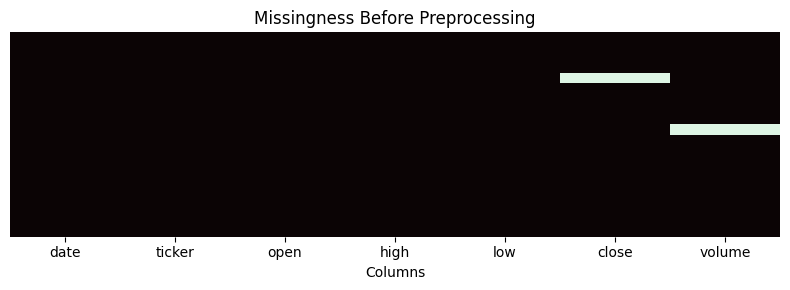

In [3]:
missing_before = missingness_summary(dirty_data)
display(missing_before)

plt.figure(figsize=(8, 3))
sns.heatmap(dirty_data.isna(), cbar=False, yticklabels=False, cmap='mako')
plt.title('Missingness Before Preprocessing')
plt.xlabel('Columns')
plt.tight_layout()
missingness_plot_path = PROCESSED_DIR / f'missingness_before_cleaning_{RUN_TIMESTAMP}.png'
plt.savefig(missingness_plot_path, dpi=150)
plt.show()

## Clean, Scale, and Validate
The reusable function applies the documented type corrections, missing-value rules, and feature scaling.

In [4]:
cleaned_data, cleaning_decisions = clean_market_prices(dirty_data)
validation_results = validate_cleaned_prices(cleaned_data)
print('Cleaning decisions:', cleaning_decisions)
print('Validation:', validation_results)
cleaned_data.head()

Cleaning decisions: {'invalid_dates_dropped': 1, 'close_missing_interpolated': 1, 'volume_missing_median_filled': 1}
Validation: {'no_missing_values': True, 'date_is_datetime': True, 'close_is_numeric': True, 'positive_prices': True, 'nonnegative_volume': True, 'dates_sorted': True}


,date,ticker,open,high,low,close,volume,daily_return,close_minmax,volume_zscore
0,2025-01-02,^GSPC,5903.259766,5935.089844,5829.529785,5868.55,3621680000,0.0,0.142318,-2.320262
1,2025-01-03,^GSPC,5891.069824,5949.339844,5888.660156,5942.47,3667340000,0.012596,0.395755,-2.184069
2,2025-01-06,^GSPC,5982.810059,6021.040039,5960.009766,5975.38,4940120000,0.005538,0.508588,1.612337
3,2025-01-07,^GSPC,5993.259766,6000.680176,5890.680176,5909.03,4517330000,-0.011104,0.281105,0.351253
4,2025-01-08,^GSPC,5910.660156,5927.890137,5874.779785,5881.7,4441740000,-0.004625,0.187404,0.125786


## Save the Analysis-Ready Dataset and Metadata
The processed data are saved in both a readable CSV and typed Parquet format. The JSON file records the source fixture, decisions, validation result, and output paths.

In [5]:
processed_csv_path = PROCESSED_DIR / f'sp500_prices_cleaned_{RUN_TIMESTAMP}.csv'
processed_parquet_path = PROCESSED_DIR / f'sp500_prices_cleaned_{RUN_TIMESTAMP}.parquet'
cleaned_data.to_csv(processed_csv_path, index=False)
cleaned_data.to_parquet(processed_parquet_path, index=False)

metadata = {
    'source_fixture': str(dirty_path.relative_to(REPO_ROOT)),
    'source_stage05_file': str(source_path.relative_to(REPO_ROOT)),
    'cleaning_decisions': cleaning_decisions,
    'validation_results': validation_results,
    'outputs': {
        'csv': str(processed_csv_path.relative_to(REPO_ROOT)),
        'parquet': str(processed_parquet_path.relative_to(REPO_ROOT)),
        'missingness_plot': str(missingness_plot_path.relative_to(REPO_ROOT)),
    },
}
metadata_path = RAW_DIR / f'sp500_prices_cleaning_metadata_{RUN_TIMESTAMP}.json'
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

reloaded_data = pd.read_parquet(processed_parquet_path)
assert reloaded_data.shape == cleaned_data.shape
assert validate_cleaned_prices(reloaded_data) == validation_results
print('Saved and reloaded:', processed_csv_path.name, processed_parquet_path.name, metadata_path.name)

Saved and reloaded: sp500_prices_cleaned_20260820-050305.csv sp500_prices_cleaned_20260820-050305.parquet sp500_prices_cleaning_metadata_20260820-050305.json


/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.optional.neon'. Detail: [errno 1] Operation not permitted


## Assumptions and Risks

- The missing values are deliberately injected into a teaching fixture, so the imputation choices demonstrate methods rather than infer the real missing-data mechanism.
- Interpolation assumes the missing close lies on a smooth path between observed dates; this should be reviewed for real market gaps.
- Median volume imputation is robust to large values but can still understate unusual trading activity.
- MinMax scaling is sensitive to future extreme observations, while standard scaling assumes its mean and variance are appropriate for the future sample.
- Later stages should fit scalers on training data only to prevent data leakage.